### Quickstart v2: Aggregators and Portfolio Optimizers

This notebook demonstrates the new pipeline:

- Models → Model Simulations
- Aggregators (combine model weights)
- Optional Portfolio Optimizers (asset-level, e.g., mean-variance)
- Portfolio Simulations

It uses small defaults and runs end-to-end.


In [1]:
# Set Google Application Credentials Enviroment (Only needed for 'local' poetry mode, not docker)

# Use Absolute Path for Google Application Credentials
import os
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = '/Users/charlesmaloney/Developer/github.com/Hawk-Center/trading-engine/service_account.json' # CHANGE THIS PATH
os.environ["MOSEKLM_LICENSE_FILE"] = '/Users/charlesmaloney/Developer/github.com/Hawk-Center/trading-engine/mosek.lic' # CHANGE THIS PATH

In [2]:
import polars as pl
print(f"Polars version: {pl.__version__}")


Polars version: 1.32.0


In [3]:
import datetime as dt
import polars as pl
import datetime

from trading_engine.core import (
    read_data,
    create_model_state,
    orchestrate_model_backtests,
    orchestrate_model_simulations,
    orchestrate_portfolio_aggregation,
    orchestrate_portfolio_optimizations,
    orchestrate_portfolio_simulations,
    run_full_backtest,
)
from trading_engine.models import MODELS
from trading_engine.aggregators import AGGREGATORS
from trading_engine.optimizers import PORTFOLIO_OPTIMIZERS

In [ ]:
# 1) experiment config
universe = [
  "SPY-US", "SLV-US", "GLD-US", "TLT-US", "USO-US", "UNG-US", "IXJ-US",
  "KXI-US", "JXI-US", "IXG-US", "IXN-US", "RXI-US", "MXI-US", "EXI-US",
  "IXC-US", "IEI-US", "SHY-US", "BIL-US", "JPXN-US", "INDA-US", "MCHI-US",
  "EZU-US", "IBIT-US", "ETHA-US", "VIXY-US"
]
features = ["close_momentum_10", "close_momentum_20", "close_momentum_30", "close_momentum_60", "close_momentum_90", "close_momentum_120", "close_momentum_240"]

# AMMA models defined in src/trading_engine/models/registry.py
models = [
    "TLT_AMMA",
    "IEI_AMMA",
    "SHY_AMMA",
    "BIL_AMMA",
    "SLV_AMMA",
    "GLD_AMMA",
    #"USO_AMMA",
    #"UNG_AMMA",
    "SPY_AMMA",
    "EWJ_AMMA",
    "INDA_AMMA",
    "MCHI_AMMA",
    "IBIT_AMMA",
    "ETHA_AMMA",
    "EZU_AMMA",
    #"VIXY_AMMA",
]
aggregators = ["model_mvo_amma_constrained"]
optimizers = ["miqp_mean_variance"]
initial_value = 1
start_date = datetime.date(2020, 1, 1)
end_date = datetime.date(2025, 9, 23)


In [5]:
# 8) one-shot end-to-end via run_full_backtest
results = run_full_backtest(
    universe=universe,
    features=features,
    models=models,
    aggregators=aggregators,
    portfolio_optimizers=optimizers,
    start_date=start_date,
    end_date=end_date,
    initial_value=initial_value,
)

results.keys()

/Users/charlesmaloney/Developer/github.com/Hawk-Center/trading-engine/.venv/lib/python3.11/site-packages/mosek/__init__.py:11539: UserWarning: Argument subi in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subi in putaijlist64: Incorrect array format causing data to be copied");
/Users/charlesmaloney/Developer/github.com/Hawk-Center/trading-engine/.venv/lib/python3.11/site-packages/mosek/__init__.py:11568: UserWarning: Argument subj in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subj in putaijlist64: Incorrect array format causing data to be copied");


dict_keys(['model_simulations', 'aggregation_results', 'aggregation_simulations', 'optimizer_results', 'optimizer_simulations'])

In [6]:
# # 2) build model state + prices
# lf = read_data()
# model_state, prices = create_model_state(
#     lf=lf,
#     features=features,
#     start_date=start_date,
#     end_date=end_date,
#     universe=universe,
# )

# model_state.head(), prices.head()


In [7]:
# # 3) run model backtests + simulations
# model_insights = orchestrate_model_backtests(
#     model_state=model_state,
#     models=models,
#     universe=universe,
# )

# model_simulations = orchestrate_model_simulations(
#     prices=prices,
#     model_insights=model_insights,
#     initial_value=initial_value,
# )

# list(model_insights.keys()), list(model_simulations.keys())


In [8]:
# model_simulations['amma_ibit_120_lo']["backtest_results"].head(200)

In [9]:
# # 4) aggregate model insights (new aggregator stage)
# aggregated = orchestrate_portfolio_aggregation(
#     model_insights=model_insights,
#     backtest_results=model_simulations,
#     universe=universe,
#     aggregators=aggregators,
# )

# list(aggregated.keys())


In [10]:
# # 5) optional: asset-level portfolio optimization (mean-variance)
# optimized = {}
# if portfolio_optimizers:
#     optimized = orchestrate_portfolio_optimizations(
#         prices=prices,
#         aggregated_insights=aggregated,
#         universe=universe,
#         optimizers=portfolio_optimizers,
#     )

# final = optimized if optimized else aggregated
# list(final.keys())


In [11]:
# # 6) simulate the chosen portfolio
# sims = orchestrate_portfolio_simulations(
#     prices=prices,
#     portfolio_insights=final,
#     initial_value=initial_value,
# )

# sims


In [12]:
# # 7) view summary metrics for the first portfolio
# pname, presults = next(iter(sims.items()))
# metrics = presults.get("backtest_metrics")
# metrics


In [13]:
# 9) compare aggregated vs optimized metrics (if both present)
from IPython.display import display

agg_sims = results.get("aggregation_simulations", {})
opt_sims = results.get("optimizer_simulations", {})

if agg_sims:
    agg_name, agg_sim = next(iter(agg_sims.items()))
    print(f"Aggregator: {agg_name}")
    display(agg_sim.get("backtest_metrics"))
else:
    print("No aggregation simulations found.")

if opt_sims:
    opt_name, opt_sim = next(iter(opt_sims.items()))
    print(f"\nOptimizer: {opt_name}")
    display(opt_sim.get("backtest_metrics"))
else:
    print("\nNo optimizer simulations found.")


Aggregator: model_mvo_amma_constrained


metric,value
str,f64
"""total_return""",1.095023
"""annualized_return""",0.034684
"""annualized_volatility""",0.034104
"""sharpe_ratio""",1.017012
"""sortino_ratio""",0.963665
…,…
"""num_weight_events""",5466.0
"""parsing_time_ms""",47.0
"""simulation_time_ms""",30.0



Optimizer: miqp_mean_variance


metric,value
str,f64
"""total_return""",2.694611
"""annualized_return""",0.062103
"""annualized_volatility""",0.061929
"""sharpe_ratio""",1.002811
"""sortino_ratio""",0.948558
…,…
"""num_weight_events""",5466.0
"""parsing_time_ms""",54.0
"""simulation_time_ms""",35.0


In [14]:
agg_turns = agg_sim['backtest_metrics'].filter(pl.col('metric') == 'portfolio_turnover')
opt_turns = opt_sim['backtest_metrics'].filter(pl.col('metric') == 'portfolio_turnover')

print(f"Equal Weight Aggregator Turnover: {agg_turns['value'].to_list()[0]:.4f}")
print(f"Mean Variance Optimizer Turnover: {opt_turns['value'].to_list()[0]:.4f}")
print(f"Difference: {opt_turns['value'].to_list()[0] - agg_turns['value'].to_list()[0]:.4f}")


Equal Weight Aggregator Turnover: 5.1739
Mean Variance Optimizer Turnover: 9.4748
Difference: 4.3009


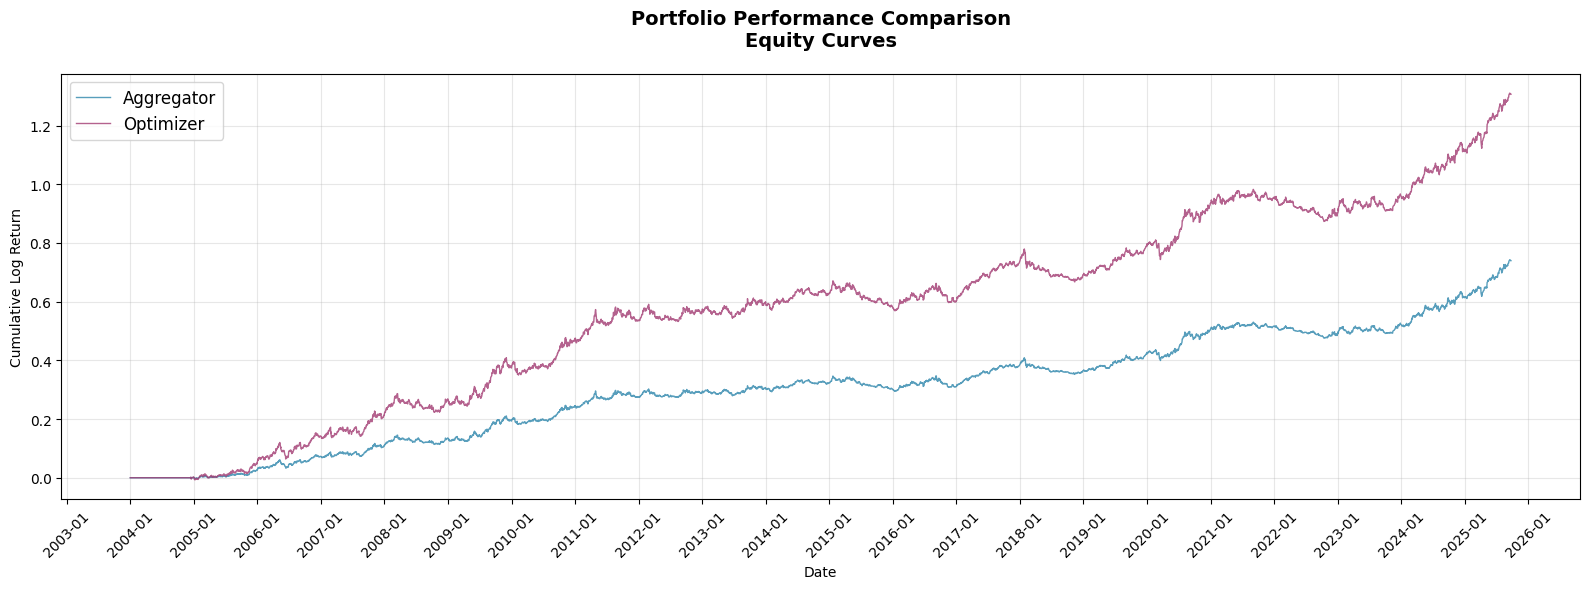


Final Performance Comparison:
Aggregator Final Return: 0.7396
OptimizerFinal Return: 1.3069
Difference: 0.5673


In [15]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# Extract data for plotting
agg_data = agg_sims['model_mvo_amma_constrained']['backtest_results'].select(['date', 'cumulative_log_return'])
opt_data = opt_sims['miqp_mean_variance']['backtest_results'].select(['date', 'cumulative_log_return'])

# Convert dates to datetime objects for better plotting
agg_dates = [datetime.strptime(date, '%Y-%m-%d') for date in agg_data['date'].to_list()]
agg_returns = agg_data['cumulative_log_return'].to_list()

opt_dates = [datetime.strptime(date, '%Y-%m-%d') for date in opt_data['date'].to_list()]
opt_returns = opt_data['cumulative_log_return'].to_list()

# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(16, 6))

# Plot both strategies on the same plot
ax.plot(agg_dates, agg_returns, linewidth=1, color='#2E86AB', alpha=0.8, label='Aggregator')
ax.plot(opt_dates, opt_returns, linewidth=1, color='#A23B72', alpha=0.8, label='Optimizer')

ax.set_title('Portfolio Performance Comparison\nEquity Curves', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=10)
ax.set_ylabel('Cumulative Log Return', fontsize=10)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# Adjust layout and display
plt.tight_layout()
plt.show()

# Print final performance comparison
print(f"\nFinal Performance Comparison:")
print(f"Aggregator Final Return: {agg_returns[-1]:.4f}")
print(f"OptimizerFinal Return: {opt_returns[-1]:.4f}")
print(f"Difference: {opt_returns[-1] - agg_returns[-1]:.4f}")
